# Image Processing Pipeline Demonstration

This notebook demonstrates the full step-by-step process for a single image, showing the original image, filtered versions, and the final binarized results.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pandas as pd

sys.path.append('../src')
import noise_filter

# Create output directory for demo images
output_dir = Path("../data/output_demo1")
output_dir.mkdir(exist_ok=True)

def show_img(img, title="Image", cmap="gray"):
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

## 1. Load Data
Select one image from the training set and its corresponding mask for the example.

Processing: palsar_22.png


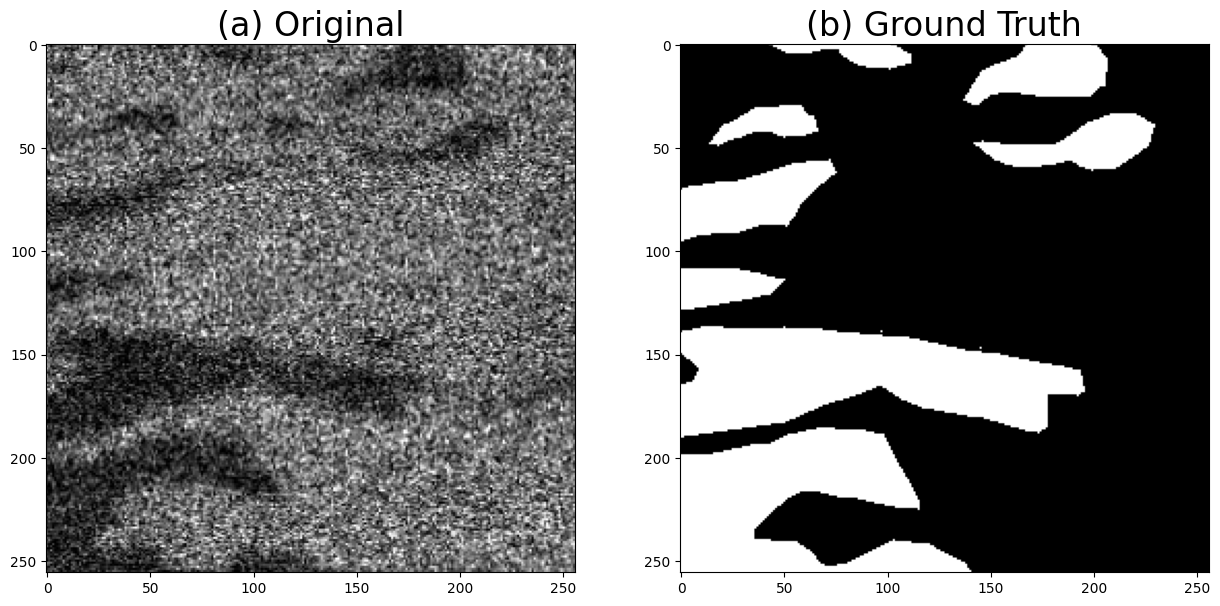

True

In [2]:
img_dir = Path("../data/images/images/train")
mask_dir = Path("../data/masks/masks/train")

# Pick the first image found
# palsar568.png
sample_path = img_dir / "palsar_22.png"
# sample_path = next(img_dir.glob("*.png"))
mask_path = mask_dir / sample_path.name

original = noise_filter.load_image(sample_path)
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

print(f"Processing: {sample_path.name}")
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(original, cmap='gray')
ax[0].set_title("(a) Original", fontsize=24)
ax[1].imshow(mask, cmap='gray')
ax[1].set_title("(b) Ground Truth", fontsize=24)
plt.savefig(output_dir/"dataset_example.png", dpi=300, bbox_inches='tight')
plt.show()
cv2.imwrite(str(output_dir / "01_original.png"), original)
cv2.imwrite(str(output_dir / "02_mask.png"), mask)

## 2. Filtering
Applying different noise reduction filters.

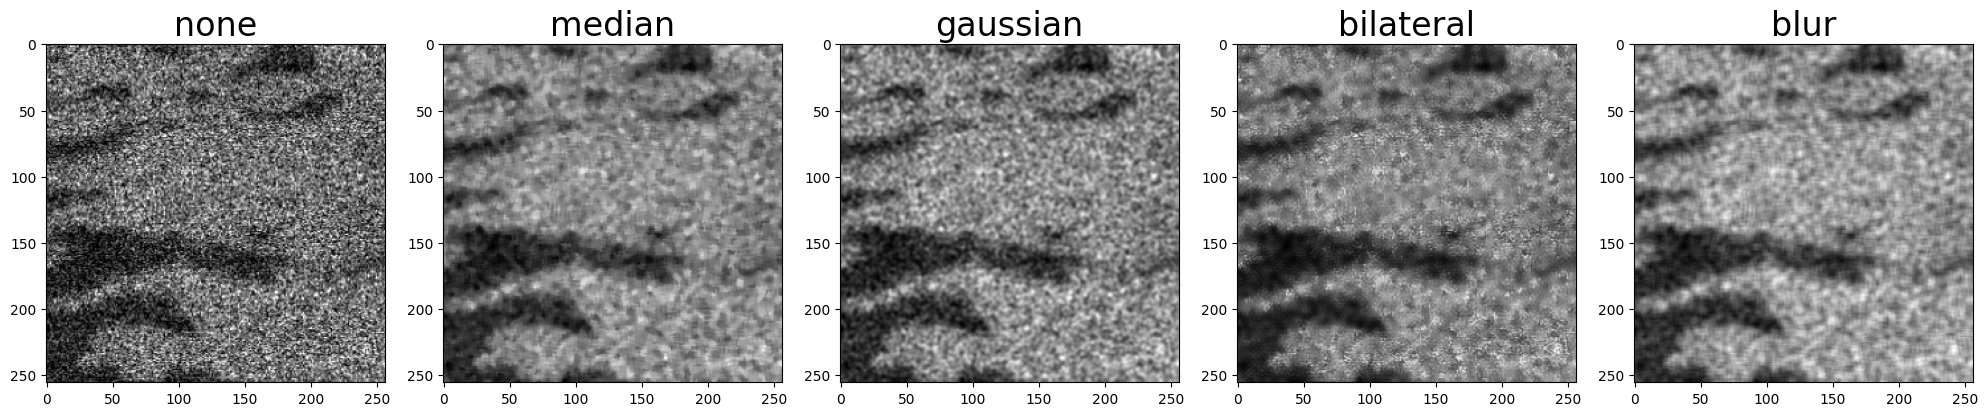

In [3]:
filters = ["none", "median", "gaussian", "bilateral", "blur"]
filtered_images = {}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, f_type in enumerate(filters):
    img_f = noise_filter.filter_img(original, f_type)
    filtered_images[f_type] = img_f
    axes[i].imshow(img_f, cmap='gray')
    axes[i].set_title(f"{f_type}", fontsize=24)
    cv2.imwrite(str(output_dir / f"03_filtered_{f_type}.png"), img_f)
    
plt.savefig(output_dir/"filter_example.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 3. Binarization
Applying binarization with optimal threshold found.

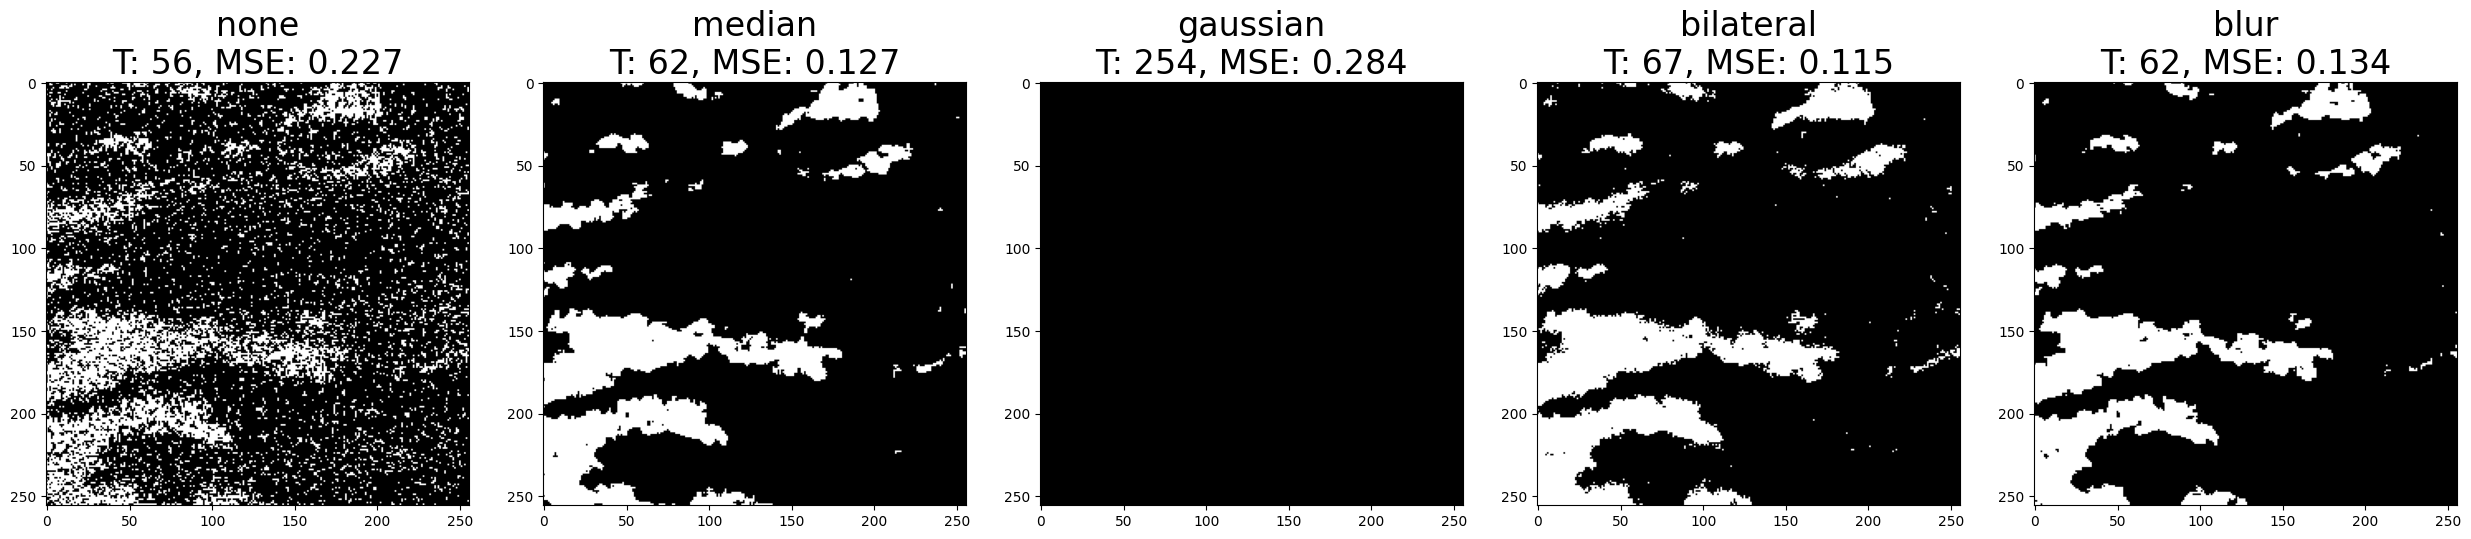

In [4]:
try:
    df_results = pd.read_csv("../experiment_results.csv")
    # Get optimal params for each filter type
    best_params = df_results.groupby("filter_type")[["threshold", "inverse"]].first().to_dict('index')
except FileNotFoundError:
    print("Warning: experiment_results.csv not found. Using default threshold 127.")
    best_params = {f: {"threshold": 127, "inverse": False} for f in filters}

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, f_type in enumerate(filters):
    img_to_bin = original if f_type == "none" else filtered_images[f_type]
    params = best_params.get(f_type, {"threshold": 127, "inverse": False})
    
    binarized = noise_filter.binarization(img_to_bin, params['threshold'], inverse=params['inverse'])
    mse = noise_filter.mean_squared_error(binarized, mask)
    
    axes[i].imshow(binarized, cmap='gray')
    axes[i].set_title(f"{f_type}\nT: {params['threshold']}, MSE: {mse:.3f}", fontsize=24)
    cv2.imwrite(str(output_dir / f"04_binarized_{f_type}.png"), binarized)

plt.savefig(output_dir/"binarization_example.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 4. Overlay Visualization

Overlaying the binarized result on the original image with a distinct color.

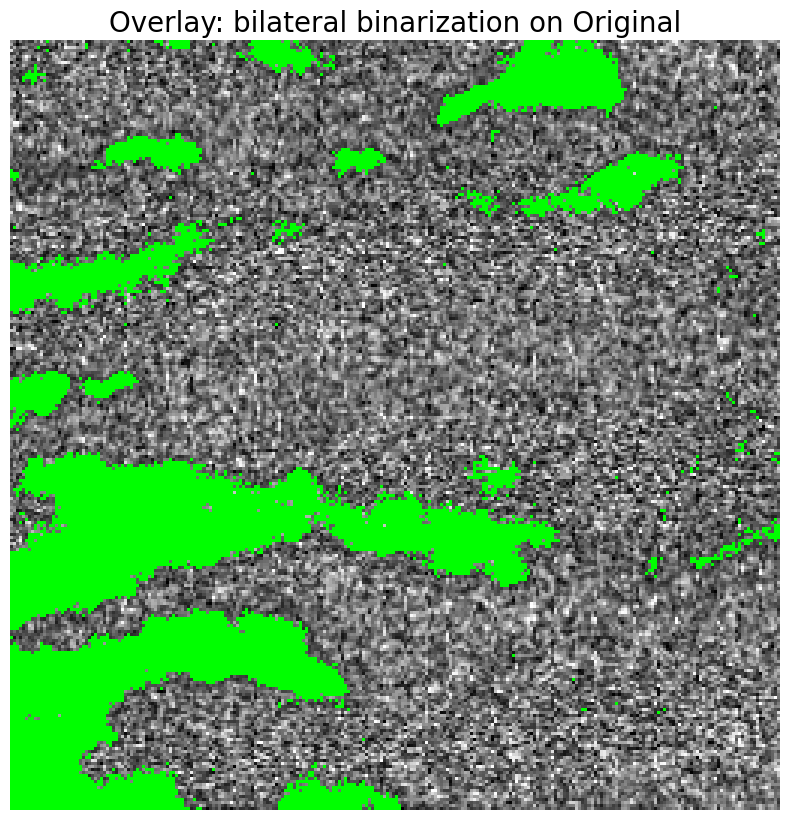

True

In [ ]:
best_filter = "bilateral"
img_to_bin = filtered_images[best_filter]
params = best_params.get(best_filter, {"threshold": 127, "inverse": False})
binarized = noise_filter.binarization(img_to_bin, params['threshold'], inverse=params['inverse'])

# Create RGB overlay
overlay = cv2.cvtColor(original, cv2.COLOR_GRAY2RGB)

overlay[binarized == 255] = [0, 255, 0]

plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.title(f"Overlay: {best_filter} binarization on Original", fontsize=20)
plt.axis('off')
plt.savefig(output_dir/"overlay_example.png", dpi=300, bbox_inches='tight')
plt.show()
cv2.imwrite(str(output_dir / "05_overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

## 5. Threshold Sweep GIF

Generating a GIF to visualize how different threshold values affect the binarization using the bilateral filter. Each frame corresponds to a threshold $T \in [0, 255]$.

In [ ]:
from PIL import Image

# Create gif directory
gif_dir = output_dir / "gif"
gif_dir.mkdir(exist_ok=True)

frames = []
bilateral_filtered = filtered_images["bilateral"]

print("Generating frames for GIF (T=0 to 255)...")
for t in range(0, 256):
    bin_img = noise_filter.binarization(bilateral_filtered, t, True)
    
    frame_path = gif_dir / f"bin_T_{t:03d}.png"
    cv2.imwrite(str(frame_path), bin_img)
    
    scale_factor = 2
    h, w = bin_img.shape
    new_h, new_w = h * scale_factor, w * scale_factor
    scaled_img = cv2.resize(bin_img, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    
    padding = 80
    canvas = np.full((new_h + padding, new_w), 255, dtype=np.uint8)
    canvas[0:new_h, 0:new_w] = scaled_img
    
    text = f"T = {t}"
    font_scale = 1.2
    thickness = 2
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)[0]
    text_x = (new_w - text_size[0]) // 2
    text_y = new_h + (padding + text_size[1]) // 2
    cv2.putText(canvas, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0), thickness)
    
    frames.append(Image.fromarray(canvas))

gif_path = output_dir / "bilateral_threshold_sweep.gif"
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=80, # 80ms per frame
    loop=0
)
print(f"GIF saved at: {gif_path}")
print(f"Individual frames saved in: {gif_dir}")

Generating frames for GIF (T=0 to 255)...
GIF saved at: ../data/output_demo1/bilateral_threshold_sweep.gif
Individual frames saved in: ../data/output_demo1/gif
